# Pyomo.DAE Example: Race Car

Adapted from [](./PyomoDAE_example.ipynb) and https://github.com/Pyomo/pyomo/blob/master/examples/dae/car_example.py

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 8 rewritten and 3 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

### Solver transcripts, mesh evidence, and reproducibility

The two `tee=True` outputs above are the full IPOPT transcripts for this example. They are useful when you need to inspect the transcribed NLP rather than only the ODE: with Radau collocation (`ncp=3`) and piecewise-constant controls, the coarse `N=10` model has 153 variables and 144 equality constraints; the fine `N=100` model has 1503 and 1404. The observed final times are 16.5783 s and 16.4711 s, respectively.

The conclusion is about the **mesh**, not a universal iteration-count rule: the coarse mesh traps the bang-bang switch inside one element, while the finer mesh resolves it. The stored outputs show one successful run; rerunning the cells is the authoritative way to obtain solver output for your environment. The archived `race-car-control` and `race-car-states` result files let the figures be redrawn without rerunning IPOPT.

```{note}
Iteration counts and timings are environment-dependent. Record the Pyomo and IPOPT versions, IPOPT linear solver, operating system, processor, and discretization (`nfe`, `ncp`, scheme, and any control reduction) before comparing runs. The stored transcript was generated with IPOPT 3.13.2 from the IDAES build and linear solver `ma27`; it is evidence for this configuration, not a performance guarantee.
```


## Learning Objectives

* Introduces syntax for Pyomo.DAE
* Shows time-scaling modeling trick
* Practice using the [units](https://pyomo.readthedocs.io/en/stable/advanced_topics/units_container.html)
  feature in Pyomo, and learn **where** in the workflow to check them
  (see [](./units_and_pyomo_dae.md))

## Install Packages and Load Modules

In [1]:
# Imports
import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

In [2]:
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import pyomo.dae as dae
from pyomo.environ import units
from pyomo.util.check_units import assert_units_consistent

## Problem Statement and Optimal Control Formulation

You are a race car driver with a simple goal. Drive distance $L$ in the minimal amount of time **but** come to a complete stop at the finish line.

Mathematically, you want to solve the following optimal control problem:

$$\begin{align*}
\min_{u,t_f} \quad & t_f \\
\mathrm{s.t.} \quad & \frac{dx}{dt} = v \\
& \frac{dv}{dt} = u - R v^2 \\
& x(t=0) = 0, ~~ x(t=t_f) = L \\
& v(t=0) = 0, ~~ v(t=t_f) = 0 \\
& -3 \leq u \leq 1
\end{align*}$$

where $u$ is the acceleration/braking (your control variable) and $R$ is the drag coefficient (parameter).

### Scale Time

Let $t = \tau \cdot t_f$ where $\tau \in [0,1]$. Thus $dt = t_f d\tau$. The optimal control problem becomes:

$$\begin{align*}
\min_{u,t_f} \quad & t_f \\
\mathrm{s.t.} \quad & \frac{dx}{d\tau} = t_f v \\
& \frac{dv}{d\tau} = t_f (u - R v^2) \\
& x(\tau = 0) = 0, ~~ x(\tau = 1) = L \\
& v(\tau = 0) = 0, ~~ v(\tau = 1) = 0 \\
& -3 \leq u \leq 1
\end{align*}$$

### Declaring our Model with Pyomo.DAE

We can use `Pyomo.dae` to automatically formulate the collocation equations (i.e., add constraints that numerically integrate the ODE model).

In [3]:
def create_model1():

    # Define the  model
    m = pyo.ConcreteModel()

    # Define the model parameters
    m.R = pyo.Param(initialize=0.001, units=1 / units.m)  # Friction factor
    m.L = pyo.Param(initialize=100.0, units=units.m)  # Final position

    # Define time
    m.tau = dae.ContinuousSet(bounds=(0, 1))  # Dimensionless time set
    m.tf = pyo.Var(initialize=1, units=units.s)  # Final time

    # Define remaining algebraic variables
    m.x = pyo.Var(m.tau, bounds=(0, m.L + 50 * units.m), units=units.m)  # Position
    m.v = pyo.Var(m.tau, bounds=(0, None), units=units.m / units.s)  # Velocity
    m.u = pyo.Var(
        m.tau, bounds=(-3.0, 1.0), initialize=0, units=units.m / units.s / units.s
    )  # Acceleration

    # Define derivative variables.
    #
    # Units MUST be given explicitly: DerivativeVar defaults to dimensionless and
    # does NOT inherit units from the state variable. Because tau is dimensionless,
    # d/dtau has the SAME units as the state itself.
    m.dx = dae.DerivativeVar(m.x, units=units.m)
    m.dv = dae.DerivativeVar(m.v, units=units.m / units.s)

    # Declare the objective (minimize final time)
    m.obj = pyo.Objective(expr=m.tf)

    # Define the constraints
    # position
    @m.Constraint(m.tau)
    def ode1(m, i):
        if i == 0:
            return pyo.Constraint.Skip
        return m.dx[i] == m.tf * m.v[i]

    # velocity
    @m.Constraint(m.tau)
    def ode2(m, i):
        if i == 0:
            return pyo.Constraint.Skip
        return m.dv[i] == m.tf * (m.u[i] - m.R * m.v[i] ** 2)

    # Define the initial/boundary conditions
    def _init(m):
        yield m.x[0] == 0
        yield m.x[1] == m.L
        yield m.v[0] == 0
        yield m.v[1] == 0

    m.initcon = pyo.ConstraintList(rule=_init)

    # Check dimensional consistency HERE, on the continuous model, BEFORE the
    # discretization equations are added. See ./units_and_pyomo_dae.md and
    # https://github.com/Pyomo/pyomo/issues/1790
    assert_units_consistent(m)

    return m


m = create_model1()

Now let's inspect the model.

In [4]:
m.pprint()

2 Param Declarations
    L : Size=1, Index=None, Domain=Any, Default=None, Mutable=True, Units=m
        Key  : Value
        None : 100.0
    R : Size=1, Index=None, Domain=Any, Default=None, Mutable=True, Units=1/m
        Key  : Value
        None : 0.001

4 Var Declarations
    tf : Size=1, Index=None, Units=s
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :  None :     1 :  None : False : False :  Reals
    u : Size=2, Index=tau, Units=m/s**2
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          0 :  -3.0 :     0 :   1.0 : False : False :  Reals
          1 :  -3.0 :     0 :   1.0 : False : False :  Reals
    v : Size=2, Index=tau, Units=m/s
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          0 :     0 :  None :  None : False :  True :  Reals
          1 :     0 :  None :  None : False :  True :  Reals
    x : Size=2, Index=tau, Units=m
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          0 :     0 :

### Aside: checking units, and *when* to check them

Notice where `assert_units_consistent(m)` sits in `create_model1` above: at the very
end of the model-building function, **before** any discretization is applied.

```{warning}
For a `Pyomo.dae` model, `assert_units_consistent` can pass on the continuous model
and then **fail after discretization**. The discretization equations that Pyomo
writes for you multiply state variables by a numerical reciprocal-$\Delta t$
coefficient, and that coefficient is dimensionless because a `ContinuousSet` cannot
carry units. This is [Pyomo issue #1790](https://github.com/Pyomo/pyomo/issues/1790),
which is still open.

**Always assert before you discretize.** You lose nothing: the discretization
equations are generated by Pyomo, not written by you, so they are not where your
modeling mistakes live.
```

Two details in the code above are worth pausing on.

1. **`DerivativeVar` does not inherit units.** It defaults to *dimensionless*. A model
   can look thoroughly annotated and still fail the very first check. Before this
   notebook declared `units=` on `m.dx` and `m.dv`, `assert_units_consistent` failed
   immediately with `dimensionless not compatible with meter` -- even though every
   `Var` and `Param` had units.
2. **The units of $dx/d\tau$ are metres, not metres per second.** We scaled time, so
   $\tau$ is dimensionless and the derivative carries the same units as the state.

That second point has a pleasant consequence, explored in the cell below.

See [](./units_and_pyomo_dae.md) for the full story, including what the check does
*not* look at (`Var` bounds and `.fix()` values are never checked).


In [5]:
# The time-scaling trick has a side benefit: because tau is DIMENSIONLESS, the
# finite-difference/collocation coefficients really are dimensionless, so this model
# passes the units check BEFORE and AFTER discretization.
#
# Do not generalize from this! It is a happy accident of scaling time to [0, 1].
# A model whose ContinuousSet is time-in-seconds fails after discretization --
# see notebooks/3/PyomoDAE_TCLab.ipynb for that case.

m_demo = create_model1()  # assert_units_consistent already ran inside
print("Before discretization: units are consistent.")

pyo.TransformationFactory("dae.collocation").apply_to(
    m_demo, nfe=15, scheme="LAGRANGE-RADAU", ncp=3
)

try:
    assert_units_consistent(m_demo)
    print("After discretization:  units are STILL consistent (tau is dimensionless).")
except Exception as e:
    print("After discretization:  FAILED ->", e)

Before discretization: units are consistent.
After discretization:  units are STILL consistent (tau is dimensionless).


### Discretize/Transcribe and Solve

`Pyomo.dae` writes the collocation equations for us. The only knob that matters
below is `nfe`, the number of finite elements: it does not change the model,
only how finely the discretization can resolve it. We solve the **same model on
two meshes** and compare.

Notice what `tee=True` prints before the iteration table -- Ipopt reports how
many variables and equality constraints the collocation equations produced.
That count, not the size of the ODE, is what the solver actually sees.

In [6]:
# COARSE mesh: N = 10 finite elements.
#
# N = 10 is chosen, not arbitrary. The optimal control here is bang-bang: full
# throttle (u = +1) until one switching time, then full braking (u = -3) to the
# line. At N = 10 that switching time falls strictly INSIDE a finite element,
# and because reduce_collocation_points holds u constant across an element, the
# only way the discretized problem can say "switch part-way through this
# element" is to give the WHOLE element an intermediate value. Watch for it
# below: one element sits at u = -0.52 m/s^2 for 1.7 s -- a braking level the
# true optimal control never uses. That is an artifact of the mesh, not physics.

NFE_COARSE = 10

m_coarse = create_model1()

# Declare the discretizer
discretizer = pyo.TransformationFactory("dae.collocation")
discretizer.apply_to(m_coarse, nfe=NFE_COARSE, scheme="LAGRANGE-RADAU", ncp=3)

# force piecewise constant controls (acceleration) over each finite element
m_coarse = discretizer.reduce_collocation_points(
    m_coarse, var=m_coarse.u, ncp=1, contset=m_coarse.tau
)

# Solve. tee=True prints Ipopt's own log: first the problem-size block -- how
# many variables and equality constraints the collocation equations produced --
# and then the iteration table.
solver = pyo.SolverFactory("ipopt")
solve_status = solver.solve(m_coarse, tee=True)
assert pyo.check_optimal_termination(solve_status), (
    f"Solve failed: status={solve_status.solver.status}, "
    f"termination={solve_status.solver.termination_condition}"
)

print("final time = %6.2f seconds" % (pyo.value(m_coarse.tf)))

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

final time =  16.58 seconds


## Finer Time Discretization

Does the intermediate braking force go away if we consider a finer time
discretization?

In [7]:
# FINE mesh: N = 100 finite elements.
#
# The same problem on a mesh ten times finer. Nothing about the model changes;
# only nfe does. The switching element is still there -- it always is, because
# the switch almost never lands exactly on an element boundary -- but it is now
# 0.16 s wide instead of 1.7 s, so the control profile looks like the bang-bang
# solution it is approximating, and the objective stops moving.

NFE_FINE = 100

m_fine = create_model1()

# Declare the discretizer
discretizer = pyo.TransformationFactory("dae.collocation")
discretizer.apply_to(m_fine, nfe=NFE_FINE, scheme="LAGRANGE-RADAU", ncp=3)

# force piecewise constant controls (acceleration) over each finite element
m_fine = discretizer.reduce_collocation_points(
    m_fine, var=m_fine.u, ncp=1, contset=m_fine.tau
)

# Solve. tee=True prints Ipopt's own log: first the problem-size block -- how
# many variables and equality constraints the collocation equations produced --
# and then the iteration table.
solver = pyo.SolverFactory("ipopt")
solve_status = solver.solve(m_fine, tee=True)
assert pyo.check_optimal_termination(solve_status), (
    f"Solve failed: status={solve_status.solver.status}, "
    f"termination={solve_status.solver.termination_condition}"
)

print("final time = %6.2f seconds" % (pyo.value(m_fine.tf)))

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

  22  3.6362628e+01 1.46e+00 9.35e+04  -1.0 5.53e+02    -  2.53e-01 4.03e-02f  1
  23  3.6118968e+01 1.76e-02 3.88e-02  -1.0 2.17e+00  -2.2 1.00e+00 1.00e+00f  1
  24  1.8378466e+01 4.38e+01 1.79e+03  -3.8 2.69e+03    -  4.01e-02 3.69e-02f  1
  25  1.5215375e+01 3.35e+01 2.33e+05  -3.8 7.92e+01    -  4.80e-03 4.44e-01h  1
  26  1.7890203e+01 2.54e+00 4.80e+05  -3.8 2.13e+01    -  6.56e-02 9.49e-01h  1
  27  1.7667756e+01 9.11e-02 3.88e+04  -3.8 6.04e+00    -  9.22e-01 1.00e+00h  1
  28  1.6829488e+01 1.39e+00 1.55e+04  -3.8 2.94e+01    -  5.99e-01 9.44e-01h  1


  29  1.6614032e+01 3.34e-01 4.95e+03  -3.8 2.29e+01    -  6.81e-01 8.75e-01h  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  30  1.6538014e+01 1.20e-01 1.51e+03  -3.8 2.66e+01    -  6.95e-01 8.59e-01h  1
  31  1.6517013e+01 1.80e-02 1.99e+02  -3.8 1.42e+01    -  8.68e-01 1.00e+00h  1
  32  1.6515413e+01 6.12e-04 3.73e-08  -3.8 6.32e+00    -  1.00e+00 1.00e+00h  1
  33  1.6472038e+01 1.23e-02 1.22e+03  -5.7 4.66e+00    -  9.18e-01 1.00e+00h  1
  34  1.6471688e+01 5.61e-06 2.69e-09  -5.7 2.67e-01    -  1.00e+00 1.00e+00h  1
  35  1.6471138e+01 1.74e-06 7.86e-09  -8.6 5.09e-02    -  1.00e+00 1.00e+00h  1
  36  1.6471138e+01 1.21e-11 2.55e-14  -8.6 1.51e-04    -  1.00e+00 1.00e+00h  1

Number of Iterations....: 36

                                   (scaled)                 (unscaled)
Objective...............:   1.6471137966472515e+01    1.6471137966472515e+01
Dual infeasibility......:   2.5492694953627627e-14    2.5492694953627627e-14
Constraint viol

final time =  16.47 seconds


## Comparing the Two Meshes

Both solves are done, so pull the trajectories out of the two models and
archive them. Separating "solve" from "analyze" is a habit worth keeping: the
plotting cells below then depend only on `results`, and can be re-run without a
solver.

In [8]:
def extract_race_car_results(m, nfe):
    """Pull the solved trajectories out of a Pyomo model into plain lists.

    Arguments:
        m: solved, discretized race-car model
        nfe: number of finite elements used, for the label

    Returns:
        dict of JSON-safe values -- everything the figures need and nothing else

    The time axis is rebuilt here: the model is written in dimensionless time
    tau in [0, 1], so physical time is t = tau * t_f, and t_f is itself a
    decision variable. Two meshes therefore have DIFFERENT final times, which
    is the number the mesh-refinement argument turns on.
    """
    tf = pyo.value(m.tf)
    tau = sorted(m.tau)
    return {
        "label": f"N = {nfe}",
        "nfe": nfe,
        "tf": tf,
        "t": [i * tf for i in tau],  # time [s]
        "x": [pyo.value(m.x[i]) for i in tau],  # position [m]
        "v": [pyo.value(m.v[i]) for i in tau],  # velocity [m/s]
        "u": [pyo.value(m.u[i]) for i in tau],  # acceleration [m/s^2]
        # Element boundaries in physical time, so a figure can show WHERE the
        # control is allowed to change value.
        "elements": [b * tf for b in m.tau.get_finite_elements()],
    }


results = {
    "meshes": [
        extract_race_car_results(m_coarse, NFE_COARSE),
        extract_race_car_results(m_fine, NFE_FINE),
    ],
    "u_lower": -3.0,  # [m/s^2]
    "u_upper": 1.0,  # [m/s^2]
    "L": 100.0,  # [m]
}

for mesh in results["meshes"]:
    print(f"{mesh['label']:>8}:  t_f = {mesh['tf']:.4f} s")

DESCRIPTION = (
    "Minimum-time race car (m = 1, L = 100 m, drag R = 0.001 1/m, "
    "-3 <= u <= 1), solved with Pyomo.dae LAGRANGE-RADAU collocation, ncp = 3, "
    "with the control reduced to piecewise constant on each element. Two "
    "meshes: N = 10, coarse enough that the bang-bang switch is trapped inside "
    "one element and that element takes an intermediate braking value, and "
    "N = 100, where the switch is resolved."
)

for figure_name in ("race-car-control", "race-car-states"):
    helper.save_results(
        figure_name,
        results,
        notebook="notebooks/3-dev/PyomoDAE_car.ipynb",
        source_tag="handout:race-car-model",
        description=DESCRIPTION,
        solver="Ipopt 3.13.2 (IDAES build, linear solver ma27)",
    )

  N = 10:  t_f = 16.5783 s
 N = 100:  t_f = 16.4711 s


[helper] wrote figures/results/race-car-control.json
[helper] wrote figures/results/race-car-states.json


### The control profile

This is where the two meshes disagree.

[helper] wrote media/figures/race-car-control.png and .pdf


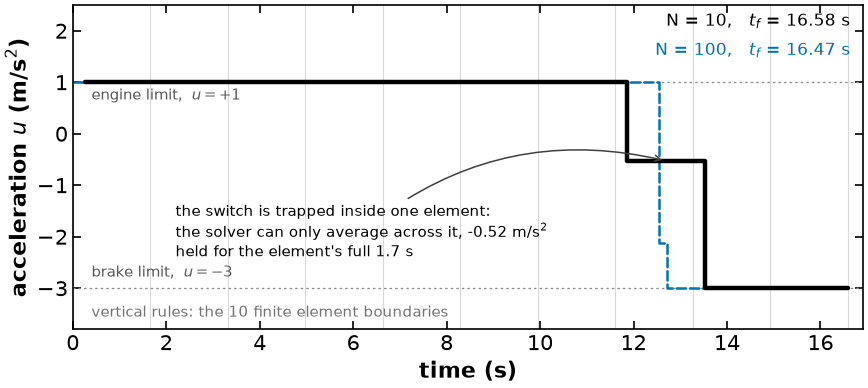

In [9]:
# This cell is tagged `figure:race-car-control', which makes it the single
# source of the control-profile figure the Lecture 7 handout prints.
# figures/render_from_notebook.py re-runs exactly this cell against the archived
# JSON when the house style changes, so there is no second copy of the plotting
# code. That driver binds `np', `plt' and `helper' for the cell, so it imports
# nothing and uses no name defined in an earlier cell except `results'.


def plot_race_car_control(results):
    """The control profile on both meshes, and what the coarse mesh gets wrong.

    THE FIGURE'S POINT is the flat step at u ~ -0.5 in the coarse profile. The
    exact solution is bang-bang -- it takes only the two bound values -- so any
    element sitting between them is the discretization confessing that it put
    the switching time inside an element and had to average across it. On the
    fine mesh the same element is a tenth as wide and the profile reads as the
    step function it approximates.

    STEPS, NOT LINES. The control really is piecewise constant over an element
    (that is what reduce_collocation_points enforces), so drawstyle="steps-post"
    draws what the NLP contains. A plain line would interpolate diagonally
    across the switch and show a smooth ramp that no variable in the model
    represents.

    ⚠ tau = 0 IS DROPPED from the control series. u[0] is not a control the
    solver uses -- the reduced control is indexed by element, and the first
    element's value lives at its first collocation point -- so plotting u[0]
    puts a spurious step from its initialize=0 value at the left edge.

    ELEMENT RULES, coarse mesh only. The light vertical lines are the finite
    element boundaries: the control is constant between two of them by
    construction, so the rules explain the staircase rather than decorating it.
    Drawing them for N = 100 would be a grey block.

    GREYSCALE. Two series, each taking colour AND linestyle together from the
    house prop_cycle (figures/dowling.mplstyle pairs the two element-wise),
    plus different line widths, plus a direct label beside each curve. Any one
    of those is enough on a photocopy.
    """
    meshes = results["meshes"]
    coarse = meshes[0]
    u_lo, u_hi = results["u_lower"], results["u_upper"]
    t_max = max(m["tf"] for m in meshes)
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(figsize=(9.0, 4.2))

    # Element boundaries FIRST, so they sit under the data.
    for b in coarse["elements"]:
        ax.axvline(b, color="0.85", linewidth=0.8, zorder=0)

    for u_bound in (u_hi, u_lo):
        ax.axhline(
            u_bound, color="0.55", linewidth=1.0, linestyle=(0, (1, 3)), zorder=1
        )

    for k, mesh in enumerate(meshes):
        t = mesh["t"][1:]
        u = mesh["u"][1:]
        ax.plot(
            t, u, drawstyle="steps-post", linewidth=3.2 if k == 0 else 1.8, zorder=3 - k
        )

    # The defect, called out where it happens. Exactly one coarse element sits
    # strictly between the bounds; find it rather than hard-coding a time.
    tol = 1e-3
    trapped = [
        (t, u)
        for t, u in zip(coarse["t"][1:], coarse["u"][1:])
        if u_lo + tol < u < u_hi - tol
    ]
    if trapped:
        t_bad = trapped[len(trapped) // 2][0]
        u_bad = trapped[0][1]
        ax.annotate(
            "the switch is trapped inside one element:\n"
            f"the solver can only average across it, {u_bad:+.2f} m/s$^2$\n"
            f"held for the element's full {coarse['tf'] / coarse['nfe']:.1f} s",
            xy=(t_bad, u_bad),
            xytext=(0.13, 0.30),
            textcoords="axes fraction",
            ha="left",
            va="center",
            fontsize=11,
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.1,
                color="0.25",
                connectionstyle="arc3,rad=-0.25",
            ),
        )

    # DIRECT LABELS, not a legend: the two profiles coincide for most of the
    # horizon, so a legend box would sit somewhere the eye has to travel to.
    # They go ABOVE the engine-limit line -- headroom made by the ylim below,
    # because every other corner of these axes has a curve or a rule in it.
    for k, mesh in enumerate(meshes):
        ax.annotate(
            f"{mesh['label']},   $t_f$ = {mesh['tf']:.2f} s",
            xy=(0.985, 0.95 - 0.09 * k),
            xycoords="axes fraction",
            ha="right",
            va="center",
            fontsize=12.5,
            color=colors[k],
        )

    ax.annotate(
        "engine limit,  $u = +1$",
        xy=(0.4, u_hi - 0.12),
        ha="left",
        va="top",
        fontsize=10.5,
        color="0.35",
    )
    ax.annotate(
        "brake limit,  $u = -3$",
        xy=(0.4, u_lo + 0.14),
        ha="left",
        va="bottom",
        fontsize=10.5,
        color="0.35",
    )
    ax.annotate(
        f"vertical rules: the {coarse['nfe']} finite element boundaries",
        xy=(0.4, u_lo - 0.62),
        ha="left",
        va="bottom",
        fontsize=10.5,
        color="0.45",
    )

    ax.set_xlabel("time (s)")
    ax.set_ylabel(r"acceleration $u$ (m/s$^2$)")
    ax.set_xlim(0, t_max * 1.02)
    ax.set_ylim(u_lo - 0.8, u_hi + 1.5)
    fig.tight_layout()
    return fig


fig = plot_race_car_control(results)

# Write media/figures/race-car-control.{png,pdf} -- what the lecture handout
# \includegraphics. A no-op on Colab, where there is no repo to write to.
helper.save_figure(fig, "race-car-control")

### The state trajectories

And this is where they agree -- which is the trap.

[helper] wrote media/figures/race-car-states.png and .pdf


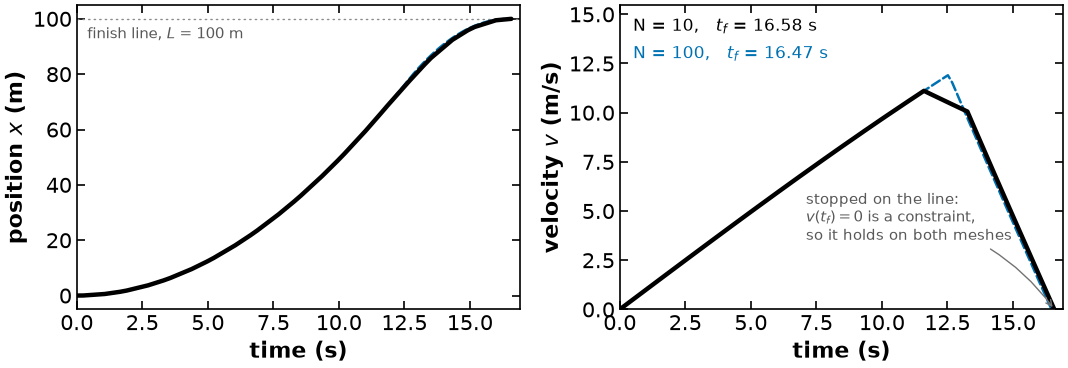

In [10]:
# Tagged `figure:race-car-states': the single source of the state-trajectory
# figure in the Lecture 7 handout. Same contract as the cell above -- it uses
# only `results', `plt' and `helper', and defines its own figsize.


def plot_race_car_states(results):
    """Position and velocity on both meshes.

    WHY THIS FIGURE SITS BESIDE THE CONTROL FIGURE. That one shows where the
    coarse discretization goes wrong; this one shows how little of it reaches
    the states. Position is visually identical on the two meshes, and the coarse
    solution still lands exactly on x = L with v = 0 -- because those are
    constraints, and a constraint holds on any mesh. What the coarse mesh gets
    wrong is the OBJECTIVE. A student reading only these two panels would
    conclude N = 10 was fine.

    THE VELOCITY PANEL IS WHERE THE DEFECT IS VISIBLE. The trapped element's
    weak braking rounds the peak of the coarse velocity curve where the fine one
    turns sharply, and the coarse car then brakes at the limit for longer to
    still stop on the line.

    GREYSCALE. Colour and linestyle move together from the house prop_cycle,
    the line widths differ, and the labels are direct rather than a legend.
    """
    meshes = results["meshes"]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    t_max = max(m["tf"] for m in meshes)

    fig, (ax_x, ax_v) = plt.subplots(1, 2, figsize=(11.0, 4.0))

    ax_x.axhline(
        results["L"], color="0.55", linewidth=1.0, linestyle=(0, (1, 3)), zorder=1
    )
    for k, mesh in enumerate(meshes):
        style = dict(linewidth=3.2 if k == 0 else 1.8, zorder=3 - k)
        ax_x.plot(mesh["t"], mesh["x"], **style)
        ax_v.plot(mesh["t"], mesh["v"], **style)

    ax_x.annotate(
        f"finish line, $L$ = {results['L']:.0f} m",
        xy=(0.4, results["L"] - 3),
        ha="left",
        va="top",
        fontsize=10.5,
        color="0.35",
    )

    # Both labels go in the empty upper-left wedge of the velocity panel, above
    # the acceleration ramp and left of the peak.
    for k, mesh in enumerate(meshes):
        ax_v.annotate(
            f"{mesh['label']},   $t_f$ = {mesh['tf']:.2f} s",
            xy=(0.03, 0.93 - 0.09 * k),
            xycoords="axes fraction",
            ha="left",
            va="center",
            fontsize=12.5,
            color=colors[k],
        )

    ax_v.annotate(
        "stopped on the line:\n$v(t_f) = 0$ is a constraint,\nso it holds on both meshes",
        xy=(meshes[0]["tf"], 0.0),
        xytext=(0.42, 0.30),
        textcoords="axes fraction",
        ha="left",
        va="center",
        fontsize=10.5,
        color="0.35",
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.0,
            color="0.45",
            connectionstyle="arc3,rad=-0.2",
        ),
    )

    ax_x.set_xlabel("time (s)")
    ax_x.set_ylabel("position $x$ (m)")
    ax_v.set_xlabel("time (s)")
    ax_v.set_ylabel("velocity $v$ (m/s)")
    for ax in (ax_x, ax_v):
        ax.set_xlim(0, t_max * 1.02)
    ax_v.set_ylim(0, max(max(m["v"]) for m in meshes) * 1.30)
    fig.tight_layout()
    return fig


fig = plot_race_car_states(results)
helper.save_figure(fig, "race-car-states")

**Discussion Questions**

Do the results make sense? What do you know about the relationships between
position, velocity, and acceleration? Do you see those relationships in the
plots?

The coarse mesh satisfies every constraint exactly and still reports a final
time 0.6% too large. Which quantity would you monitor to decide that a mesh is
fine enough -- the constraint violations, or the objective?

## Initialization experiment

Good initial values are useful insurance, but this small, well-scaled race-car model is a useful counterexample to the claim that a poor guess must fail. The following five runs use `create_model1`, `N=15`, `ncp=3`, `LAGRANGE-RADAU`, and **no** `reduce_collocation_points` call. All converged to the same final time.

| Initial values | IPOPT iterations | $t_f$ (s) |
| --- | ---: | ---: |
| default ($t_f=1$) | 81 | 16.4708 |
| all states 0; $t_f=1$ | 81 | 16.4708 |
| all states 0; $t_f=0$; $t_f \ge 10^{-3}$ | 79 | 16.4708 |
| all states 0; $t_f=0$; no lower bound | 98 | 16.4708 |
| all states 0; $t_f=10^6$ | 44 | 16.4708 |

These results were recorded with IPOPT 3.13.2 and `ma27`. They show that the solver can move this model away from a degenerate guess; they do **not** show that initialization is unimportant. A different Pyomo/IPOPT or linear-solver version, operating system, processor, scaling, or model/mesh can change iteration counts and even the behavior near a zero lower bound. To reproduce or extend the experiment, keep the configuration above fixed, record the environment, and alter one initial-value choice at a time.

For a more difficult dynamic optimization problem, start with physical state values, bound scalars such as final time away from a degenerate value, simulate before optimizing when possible, and solve a coarse mesh before refining it.


## Another Version

Another modeling option is to define an extra differential equation to compute time. The normalized-time formulation is unchanged: `tau` remains the fixed independent variable on $[0,1]$, and `tf` remains a decision variable. The additional state is useful when physical time must be available along the trajectory; otherwise, recover it after solving as $t=\tau t_f$.

$$\begin{align*}
\min_{u} \quad & t_f \\
\mathrm{s.t.} \quad & \frac{dx}{d\tau} = t_f v \\
& \frac{dv}{d\tau} = t_f (u - R v^2) \\
& \frac{dt}{d\tau} = t_f \\
& x(\tau = 0) = 0, ~~ x(\tau = 1) = L \\
& v(\tau = 0) = 0, ~~ v(\tau = 1) = 0 \\
& t(\tau = 0) = 0 \\
& -3 \leq u \leq 1
\end{align*}$$

In [11]:
def create_model2():

    # Define the  model
    m = pyo.ConcreteModel()

    # Define the model parameters
    m.R = pyo.Param(initialize=0.001, units=1 / units.m)  # Friction factor
    m.L = pyo.Param(initialize=100.0, units=units.m)  # Final position

    # Define time
    m.tau = dae.ContinuousSet(bounds=(0, 1))  # Dimensionless time set
    m.time = pyo.Var(m.tau, bounds=(0, None), units=units.s)  # Time
    m.tf = pyo.Var(initialize=1, units=units.s)  # Final time

    # Define remaining algebraic variables
    m.x = pyo.Var(m.tau, bounds=(0, m.L + 50 * units.m), units=units.m)  # Position
    m.v = pyo.Var(m.tau, bounds=(0, None), units=units.m / units.s)  # Velocity
    m.u = pyo.Var(
        m.tau, bounds=(-3.0, 1.0), initialize=0, units=units.m / units.s / units.s
    )  # Acceleration

    # Define derivative variables. tau is dimensionless, so d/dtau carries the
    # same units as the state. DerivativeVar does not infer these -- say them.
    m.dtime = dae.DerivativeVar(m.time, units=units.s)
    m.dx = dae.DerivativeVar(m.x, units=units.m)
    m.dv = dae.DerivativeVar(m.v, units=units.m / units.s)

    # Declare the objective (minimize final time)
    m.obj = pyo.Objective(expr=m.tf)

    # Define the constraints
    # position
    @m.Constraint(m.tau)
    def ode1(m, i):
        if i == 0:
            return pyo.Constraint.Skip
        return m.dx[i] == m.tf * m.v[i]

    # velocity
    @m.Constraint(m.tau)
    def ode2(m, i):
        if i == 0:
            return pyo.Constraint.Skip
        return m.dv[i] == m.tf * (m.u[i] - m.R * m.v[i] ** 2)

    # time
    @m.Constraint(m.tau)
    def ode3(m, i):
        if i == 0:
            return pyo.Constraint.Skip
        return m.dtime[i] == m.tf

    # Define the initial/boundary conditions
    def _init(m):
        yield m.x[0] == 0
        yield m.x[1] == m.L
        yield m.v[0] == 0
        yield m.v[1] == 0
        yield m.time[0] == 0

    m.initcon = pyo.ConstraintList(rule=_init)

    # Units are checked on the continuous model, before discretization.
    assert_units_consistent(m)

    return m


m = create_model2()

In [12]:
# Declare the discretizer
discretizer = pyo.TransformationFactory("dae.collocation")
discretizer.apply_to(m, nfe=15, scheme="LAGRANGE-RADAU", ncp=3)

# force piecewise constant controls (acceleration) over each finite element
m = discretizer.reduce_collocation_points(m, var=m.u, ncp=1, contset=m.tau)

# Solve
solver = pyo.SolverFactory("ipopt")
results = solver.solve(m, tee=True)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

print("final time = %6.2f seconds" % (pyo.value(m.tf)))

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

final time =  16.52 seconds
